# Introduction

This project aims to perform Exploratory Data Analysis (EDA) on the California Housing dataset to identify the key factors influencing housing prices. The analysis involves data cleaning, visualization, and feature engineering to extract meaningful insights and support data-driven decision-making.

# Objective

The main objectives of this project are:

- To understand the distribution of key variables in the dataset  
- To handle missing values using appropriate techniques  
- To analyze relationships between different features  
- To perform feature engineering for better insights  
- To identify the key factors influencing housing prices  

# Dataset Description

The dataset contains demographic, geographic, and housing-related features for different regions in California. The key features are:

- median_income: Median income of households in a block (continuous variable)
- housing_median_age: Median age of houses in a block (discrete variable)
- total_rooms: Total number of rooms in a block (continuous variable)
- total_bedrooms: Total number of bedrooms in a block (continuous variable)
- population: Total population residing in the block (discrete variable)
- households: Total number of households in the block (discrete variable)
- median_house_value: Median house price in the block (target variable)
- latitude & longitude: Geographic coordinates representing the location of the block (continuous variable)
- ocean_proximity: Categorical variable indicating the proximity of the block to the ocean(Categorical-Nominal variable)

In [49]:
#importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the Dataset
data=pd.read_csv("housing.csv")
#data #complete data_set

# Medium Income Analysis

Average Median Income : 3.87


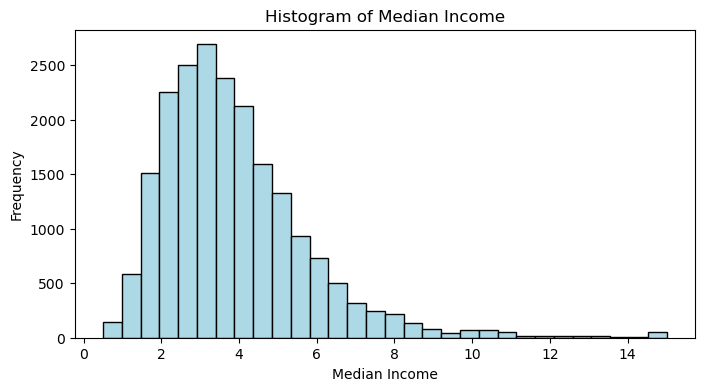

In [16]:
#average median income of data
avg_median_income=data['median_income'].mean()
print(f'Average Median Income : {avg_median_income:.2f}')

#Distribution of median_income
plt.figure(figsize=(8, 4))
plt.hist(data['median_income'],color='lightblue', bins =30, edgecolor='black')
plt.xlabel('Median Income')
plt.ylabel('Frequency')
plt.title('Distribution of Median Income')

plt.show()

Insight:
The distribution of median income is positively skewed (right-skewed), indicating that most areas have low to moderate income levels. A small number of regions have significantly higher incomes, creating a long tail on the right side. This suggests the presence of high-income outliers, which may significantly influence housing prices.

# Housing Median Age Distribution

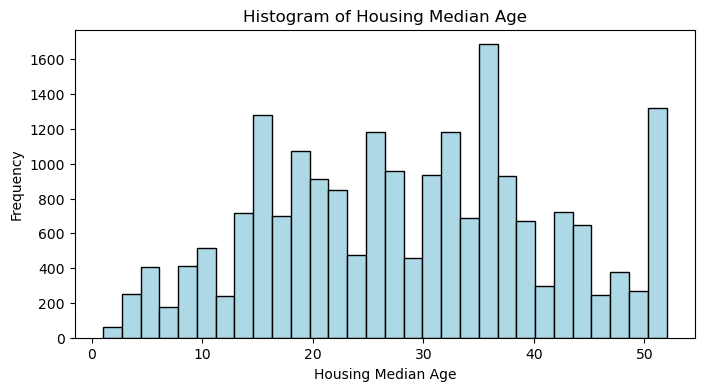

In [17]:
#distribution of housing median age
plt.figure(figsize=(8, 4))
plt.hist(data['housing_median_age'],color='lightblue',bins=30, edgecolor='black')
plt.xlabel('Housing Median Age')
plt.ylabel('Frequency')
plt.title('Distribution of Housing Median Age')

plt.show()

Insight:
The distribution of housing median age is fairly spread across different values, with a slight skew. A noticeable concentration of values is observed at the higher end, particularly around 50–52 years. This suggests that the data may be capped at an upper limit, indicating a possible constraint in the dataset rather than the true distribution of house ages.

# Income vs House value

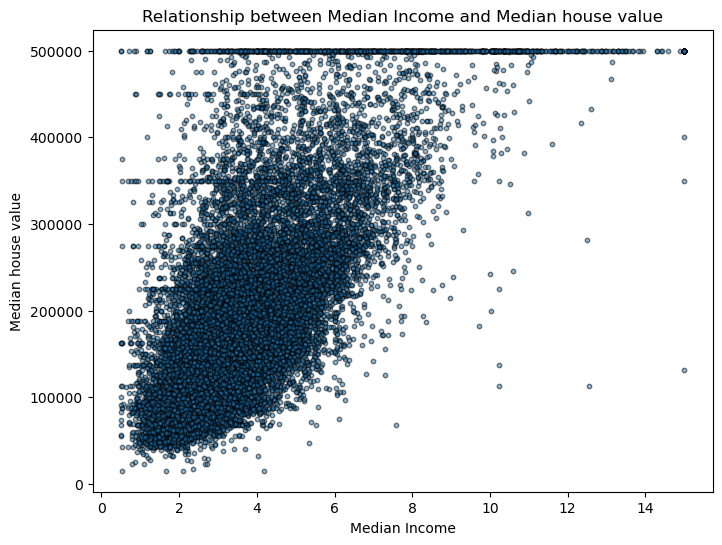

In [26]:
#visualization of relationship between median_income and median_house_value
plt.figure(figsize=(8, 6))
plt.scatter(data['median_income'],data['median_house_value'],s=10 ,alpha=.5,edgecolor='k')
plt.xlabel("Median Income") 
plt.ylabel('Median house value')
plt.title("Relationship between Median Income and Median house value")
plt.show()

Insight
The scatter plot shows a strong positive relationship between median income and median house value, indicating that higher-income areas tend to have higher housing prices. Additionally, a clear price cap is observed around 500,000, suggesting a possible upper limit or constraint in the dataset.

# Handling missing value (Attribute: total_bedrooms)

Drop Missing values

In [48]:
#removing rows with missing total_bedrooms
data_cleaned =data.dropna(subset=['total_bedrooms'])
#data_cleaned

Fill with Mean

In [47]:
#Create a data set by filling missing values of total_bedrooms
data_filled=data.copy()

#Filling missing values of total_bedrooms with the mean value of total_bedrooms
data_filled=data_filled.fillna(data['total_bedrooms'].mean())

#data_filled

# Custom Median function

In [37]:
'''A user-defined function calculate_median that takes a dataset and a column name as input and
returns the median value of that column.
This function can be reused to calculate medians wherever needed.'''

#Define a function to calculate median
def calculate_median(data,column):
  return data[column].median()

#Examples of Usage for different columns
#med_housing_median_age=calculate_median(data,'housing_median_age')
#med_median_income=calculate_median(data,'median_income')

#print(f'Median of housing median age:{med_housing_median_age : .2f}')
#print(f'Median of median income:{med_median_income : .2f}')


# Geographical Visualization

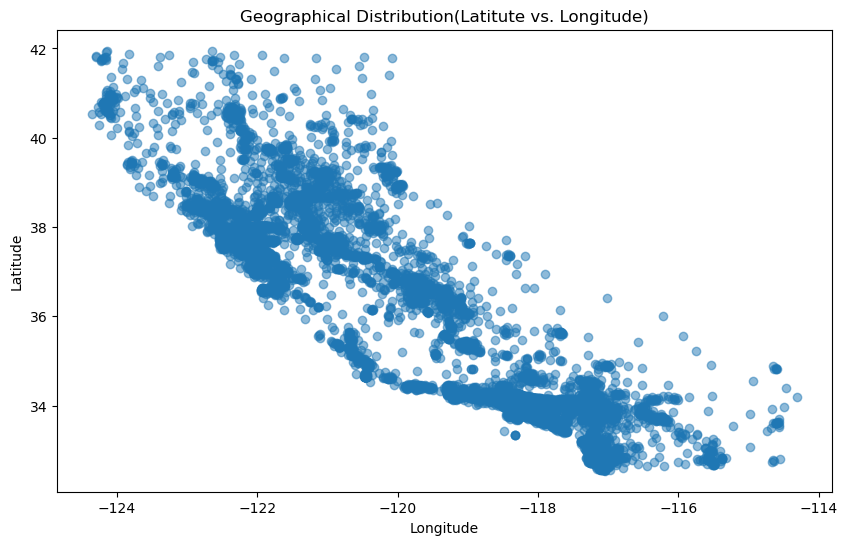

In [27]:
#visualization of latitude vs longitute
plt.figure(figsize=(10,6))
plt.scatter(data['longitude'],data['latitude'],alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Longitude')
plt.title('Geographical Distribution(Latitute vs. Longitude)')
plt.show()

Insight:
The scatter plot represents the geographical distribution of housing data across California. The data points form a map-like structure, with dense clusters observed near coastal regions, indicating higher population density in these areas. This plot is used for spatial visualization and does not represent a correlation between variables.

# Ocean Proximity Analysis

In [46]:
'''filter the dataset to create a new dataset that only contains rows where the 'ocean_proximity' column is
 'Near ocean'.'''
data_near_ocean=data[data['ocean_proximity']=='NEAR OCEAN']
#data_near_ocean

# Mean and Median of median income of data_near_ocean

In [35]:
#median and mean of median income of data_near_ocean
mean_median_income=data_near_ocean['median_income'].mean()
median_median_income=data_near_ocean['median_income'].median()
print(f'Mean of Median Income(data_near_ocean):{mean_median_income : .2f}')
print(f'Median of Median Income(data_near_ocean):{median_median_income : .2f}')

Mean of Median Income(data_near_ocean): 4.01
Median of Median Income(data_near_ocean): 3.65


Insight:
Mean > Median → Right-skewed distribution
Coastal areas generally have higher income

# Feature Engineering

In [45]:
data['rooms_per_household'] = data['total_rooms'] / data['households'] #Average number of rooms per household
#Insight:
#Higher rooms per household may indicate larger houses or less crowded living conditions.

data['bedrooms_per_room'] = data['total_bedrooms'] / data['total_rooms'] #Ratio of bedrooms to total rooms
#Insight:
#A higher ratio may indicate smaller or more crowded houses, while a lower ratio suggests more spacious homes.

#bedroom categorization
#function to categorize bedroom sizes
def categorize_bedroom_size(total_bedrooms):
    if total_bedrooms <= 10:
      return 'small'
    elif 10 < total_bedrooms < 1000:
       return 'medium'
    else:
        return 'large'

data['total_bedroom_size'] = data['total_bedrooms'].apply(categorize_bedroom_size)
#data 

# Correlation HeatMap 

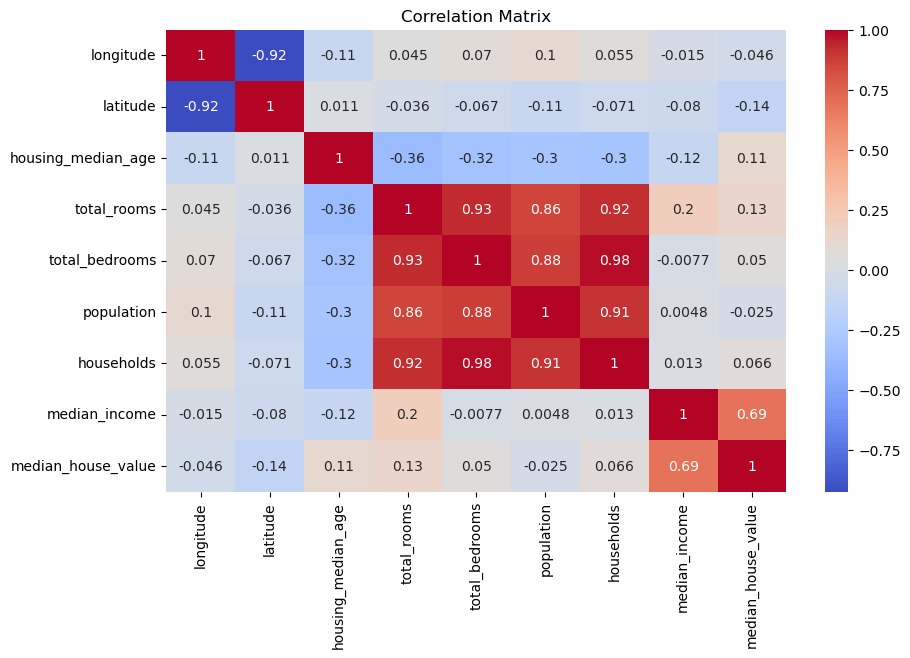

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Insight:
Median income has the strongest positive correlation with house value, making it a key influencing factor.

# Outlier 

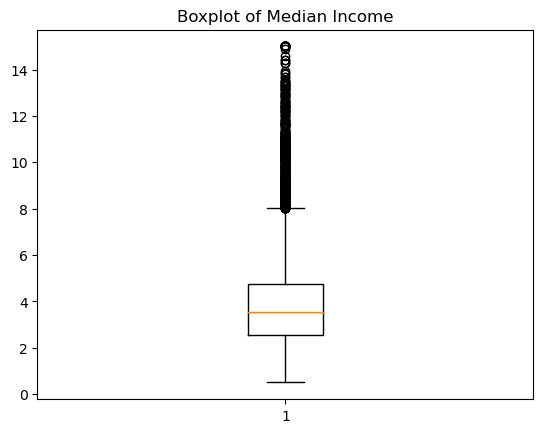

In [36]:
plt.boxplot(data['median_income'])
plt.title("Boxplot of Median Income")
plt.show()

# Key Insights

- Median income is the strongest predictor of house prices  
- Housing prices increase with income (positive correlation)  
- Dataset contains capped values (house price ~500,000 and age ~52)  
- Coastal regions have higher population density and income levels  
- Data shows presence of outliers and skewed distributions  